# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [1]:
import pandas as pd

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [2]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [6]:
df = pd.read_csv('vendas_brasil_aula1.csv')

print("Shape (linhas, colunas):")
print(df.shape)

print("\nNomes das colunas:")
print(df.columns)

print("\nInformações do dataset:")
df.info()

Shape (linhas, colunas):
(300, 9)

Nomes das colunas:
Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [7]:
df = pd.read_csv('vendas_brasil_aula1.csv')

print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nCategorias em Canal_Venda:")
print(df['Canal_Venda'].value_counts(dropna=False))

Valores nulos por coluna:
Data_Venda        0
Canal_Venda       7
UF                6
Produto           0
Preco_Unitario    5
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Categorias em Canal_Venda:
Canal_Venda
Loja Física    99
E-commerce     97
Marketplace    42
WhatsApp       37
e-commerce     10
loja fisica     8
NaN             7
Name: count, dtype: int64


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [8]:
df = pd.read_csv('vendas_brasil_aula1.csv')

receita_total = df['Receita'].sum()
lucro_total = df['Lucro'].sum()
ticket_medio = df['Receita'].mean()
quantidade_total = df['Quantidade'].sum()

print(f"Receita Total: {receita_total:.2f}")
print(f"Lucro Total: {lucro_total:.2f}")
print(f"Ticket Médio: {ticket_medio:.2f}")
print(f"Quantidade Total Vendida: {quantidade_total}")

Receita Total: 707535.36
Lucro Total: 189625.88
Ticket Médio: 2358.45
Quantidade Total Vendida: 502


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [9]:
canal_receita = df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)
print(canal_receita)

produto_lucro = df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False)
print(produto_lucro)

uf_receita = df.groupby('UF')['Receita'].sum().sort_values(ascending=False)
print(uf_receita)

Canal_Venda
E-commerce     220215.54
Loja Física    216644.15
Marketplace    111659.78
WhatsApp        85974.51
e-commerce      29122.47
loja fisica     19001.16
Name: Receita, dtype: float64
Produto
Notebook            69818.57
Smartphone          31718.11
Tablet              20936.95
Monitor             18290.52
Smartwatch          17029.45
Teclado Mecânico    12859.48
Fone Bluetooth      11647.92
Mouse Gamer          7324.88
Name: Lucro, dtype: float64
UF
SP    133727.80
MG    103438.61
RJ    100284.68
PR     69287.74
SC     63740.20
RS     51020.06
ES     50338.64
BA     46765.01
PE     42895.39
GO     25179.98
Name: Receita, dtype: float64


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

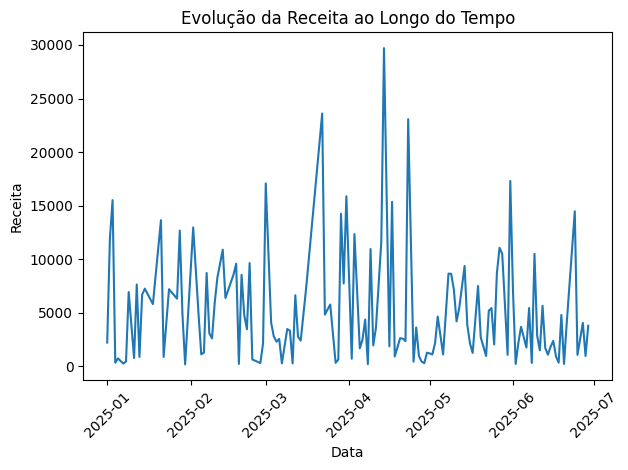

In [10]:
#a) A Evolução da receita ao longo do tempo eu usaria o gráfico de linha pois mostra bem a variação ao longo do tempo.
#b) Para cpmparar receita entre canais de venda usaria o gráfico de barras pois facilita a comparação entre categorias.
#c) Para distribuição dos preços unitários o ideal é o histograma pois mostra como os preços estão distribuidos

import matplotlib.pyplot as plt
df = pd.read_csv('vendas_brasil_aula1.csv')

df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

receita_tempo = df.groupby('Data_Venda')['Receita'].sum().sort_index()

plt.figure()
plt.plot(receita_tempo.index, receita_tempo.values)
plt.title('Evolução da Receita ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [11]:
df = pd.read_csv('vendas_brasil_aula1.csv')

print("=== ANTES ===")
print("\nValores nulos:")
print(df.isnull().sum())

print("\nCategorias Canal_Venda:")
print(df['Canal_Venda'].value_counts(dropna=False))

print("\nReceita total antes:", df['Receita'].sum())
print("Lucro total antes:", df['Lucro'].sum())

# 1. Tratar valores nulos
df['Canal_Venda'] = df['Canal_Venda'].fillna('Desconhecido')
df['UF'] = df['UF'].fillna('Desconhecido')
df['Preco_Unitario'] = df['Preco_Unitario'].fillna(df['Preco_Unitario'].mean())

# 2. Padronizar Canal_Venda
df['Canal_Venda'] = df['Canal_Venda'].str.strip().str.lower()

df['Canal_Venda'] = df['Canal_Venda'].replace({
    'e-commerce': 'E-commerce',
    'ecommerce': 'E-commerce',
    'loja fisica': 'Loja Física',
    'loja física': 'Loja Física',
    'marketplace': 'Marketplace',
    'whatsapp': 'WhatsApp',
    'desconhecido': 'Desconhecido'
})

# 3. Converter Data_Venda
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

print("\n=== DEPOIS ===")

print("\nValores nulos:")
print(df.isnull().sum())

print("\nCategorias Canal_Venda:")
print(df['Canal_Venda'].value_counts())

print("\nReceita total depois:", df['Receita'].sum())
print("Lucro total depois:", df['Lucro'].sum())

=== ANTES ===

Valores nulos:
Data_Venda        0
Canal_Venda       7
UF                6
Produto           0
Preco_Unitario    5
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Categorias Canal_Venda:
Canal_Venda
Loja Física    99
E-commerce     97
Marketplace    42
WhatsApp       37
e-commerce     10
loja fisica     8
NaN             7
Name: count, dtype: int64

Receita total antes: 707535.36
Lucro total antes: 189625.88

=== DEPOIS ===

Valores nulos:
Data_Venda        0
Canal_Venda       0
UF                0
Produto           0
Preco_Unitario    0
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Categorias Canal_Venda:
Canal_Venda
Loja Física     107
E-commerce      107
Marketplace      42
WhatsApp         37
Desconhecido      7
Name: count, dtype: int64

Receita total depois: 707535.36
Lucro total depois: 189625.88


## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**

Uma análise de dados não deve se limitar a gráficos bonitos porque o principal objetivo é gerar insights confiáveis para tomada de decisão. Visualizações sem tratamento e entendimento dos dados podem esconder erros, como valores nulos ou inconsistências. Além disso, é fundamental interpretar os resultados dentro do contexto do negócio, e não apenas apresentá-los visualmente. Uma boa análise envolve limpeza, validação, exploração e interpretação crítica. Os gráficos são apenas uma ferramenta para comunicar conclusões.
